In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors

DATA_PATH = r"D:\Data Analytics\Data Analyst Project\E-Commerce Sales & Customer Analytics Dashboard\Dataset"
OUTPUT_PATH = r"D:\Data Analytics\Data Analyst Project\E-Commerce Sales & Customer Analytics Dashboard\Dataset"

import os
master = pd.read_csv(os.path.join(DATA_PATH, "master_clean.csv"))

master['order_purchase_timestamp'] = pd.to_datetime( master['order_purchase_timestamp'])

print(f"Data loaded: {master.shape[0]:,} rows")
print(f"Date range: {master['order_purchase_timestamp'].min().date()} "
      f"to {master['order_purchase_timestamp'].max().date()}")

Data loaded: 114,630 rows
Date range: 2016-10-03 to 2018-08-29


In [10]:
reference_date = master['order_purchase_timestamp'].max() + pd.Timedelta(days=1)
print(f"Reference date (our 'today'): {reference_date.date()}")

rfm = master.groupby('customer_unique_id').agg(
    last_purchase = ('order_purchase_timestamp', 'max'),

    frequency     = ('order_id', 'nunique'),

    monetary      = ('revenue', 'sum')
).reset_index()

rfm['recency'] = (reference_date - rfm['last_purchase']).dt.days

rfm = rfm.drop(columns=['last_purchase'])

print(f"\nRFM table created: {len(rfm):,} customers")
print("\nSample RFM values (first 5 customers):")
print(rfm.head())
print("\nRFM statistics:")
print(rfm[['recency', 'frequency', 'monetary']].describe().round(2))

Reference date (our 'today'): 2018-08-30

RFM table created: 93,349 customers

Sample RFM values (first 5 customers):
                 customer_unique_id  frequency  monetary  recency
0  0000366f3b9a7992bf8c76cfdf3221e2          1    141.90      112
1  0000b849f77a49e4a4ce2b2a4ca5be3f          1     27.19      115
2  0000f46a3911fa3c0805444483337064          1     86.22      537
3  0000f6ccb0745a6a4b88665a16c9f078          1     43.62      321
4  0004aac84e0df4da2b147fca70cf8255          1    196.89      288

RFM statistics:
        recency  frequency  monetary
count  93349.00   93349.00  93349.00
mean     237.95       1.03    171.88
std      152.58       0.21    249.43
min        1.00       1.00     10.07
25%      114.00       1.00     64.00
50%      219.00       1.00    110.33
75%      346.00       1.00    187.75
max      695.00      15.00  13664.08


In [11]:

rfm['R_score'] = pd.qcut( rfm['recency'],
    q=5,                 
    labels=[5, 4, 3, 2, 1],
    duplicates='drop'   
).astype(int)

rfm['F_score'] = pd.qcut(
    rfm['frequency'].rank(method='first'),
    q=5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

rfm['M_score'] = pd.qcut(
    rfm['monetary'],
    q=5,
    labels=[1, 2, 3, 4, 5],
    duplicates='drop'
).astype(int)

rfm['RFM_score'] = (
    rfm['R_score'].astype(str) +
    rfm['F_score'].astype(str) +
    rfm['M_score'].astype(str)
)

print("RFM scores assigned:")
print(rfm[['customer_unique_id', 'recency', 'frequency',
           'monetary', 'R_score', 'F_score',
           'M_score', 'RFM_score']].head(10))

RFM scores assigned:
                 customer_unique_id  recency  frequency  monetary  R_score  \
0  0000366f3b9a7992bf8c76cfdf3221e2      112          1    141.90        4   
1  0000b849f77a49e4a4ce2b2a4ca5be3f      115          1     27.19        4   
2  0000f46a3911fa3c0805444483337064      537          1     86.22        1   
3  0000f6ccb0745a6a4b88665a16c9f078      321          1     43.62        2   
4  0004aac84e0df4da2b147fca70cf8255      288          1    196.89        2   
5  0004bd2a26a76fe21f786e4fbd80607f      146          1    166.98        4   
6  00050ab1314c0e55a6ca13cf7181fecf      132          1     35.38        4   
7  00053a61a98854899e70ed204dd4bafe      183          1    419.18        3   
8  0005e1862207bf6ccc02e4228effd9a0      543          1    150.12        1   
9  0005ef4cd20d2893f0d9fbd94d3c0d97      170          1    129.76        4   

   F_score  M_score RFM_score  
0        1        4       414  
1        1        1       411  
2        1        2     

In [12]:
def assign_segment(row):
    r = row['R_score']
    f = row['F_score']
    m = row['M_score']

    if r >= 4 and f >= 4 and m >= 4:
        return 'Champion'
    elif r >= 3 and f >= 3 and m >= 3:
        return 'Loyal Customer'
    elif r >= 4 and f <= 2:
        return 'New Customer'
    elif r >= 3 and f >= 2 and m >= 2:
        return 'Potential Loyalist'
    elif r == 3 and f <= 2:
        return 'Promising'
    elif r <= 2 and f >= 3 and m >= 3:
        return 'At Risk'
    elif r <= 2 and f >= 4 and m >= 4:
        return 'Cannot Lose Them'
    elif r <= 2 and f <= 2 and m <= 2:
        return 'Lost'
    else:
        return 'Needs Attention'

rfm['segment'] = rfm.apply(assign_segment, axis=1)

segment_summary = rfm.groupby('segment').agg(
    customer_count = ('customer_unique_id', 'count'),
    avg_recency    = ('recency', 'mean'),
    avg_frequency  = ('frequency', 'mean'),
    avg_monetary   = ('monetary', 'mean'),
    total_revenue  = ('monetary', 'sum')
).round(2).reset_index()

segment_summary = segment_summary.sort_values(
    'total_revenue', ascending=False
)

print("CUSTOMER SEGMENTS SUMMARY:")
print(segment_summary.to_string(index=False))

CUSTOMER SEGMENTS SUMMARY:
           segment  customer_count  avg_recency  avg_frequency  avg_monetary  total_revenue
           At Risk           13207       393.57           1.07        256.90     3392816.72
    Loyal Customer           14192       153.47           1.05        215.55     3059080.43
   Needs Attention           24460       323.62           1.00        121.25     2965766.46
      New Customer           14980        90.89           1.00        169.06     2532497.08
          Champion            6472        91.26           1.18        326.00     2109862.07
Potential Loyalist            9273       161.37           1.01        108.87     1009550.79
         Promising            4502       219.56           1.00        137.92      620901.72
              Lost            6263       396.51           1.00         56.50      353884.19


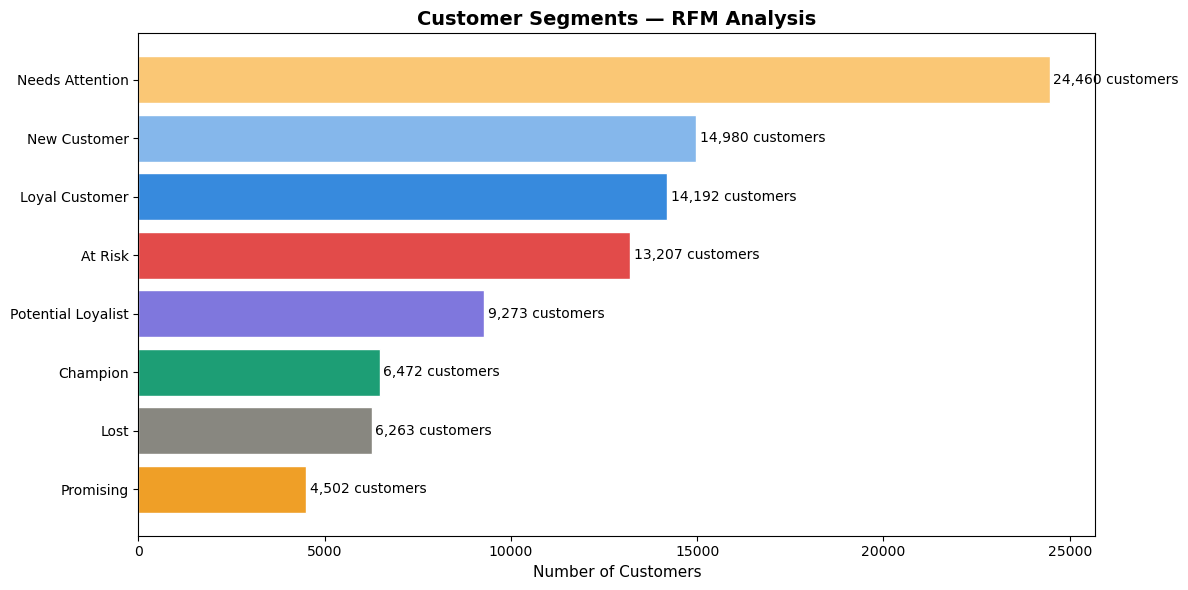

Chart saved!


In [13]:
colors_map = {
    'Champion'          : '#1D9E75',
    'Loyal Customer'    : '#378ADD',
    'Potential Loyalist': '#7F77DD',
    'New Customer'      : '#85B7EB',
    'Promising'         : '#EF9F27',
    'Needs Attention'   : '#FAC775',
    'At Risk'           : '#E24B4A',
    'Cannot Lose Them'  : '#C0392B',
    'Lost'              : '#888780'
}

seg_counts = rfm['segment'].value_counts()
bar_colors = [colors_map.get(s, '#888780') for s in seg_counts.index]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(seg_counts.index, seg_counts.values,
               color=bar_colors, edgecolor='white')

for bar, val in zip(bars, seg_counts.values):
    ax.text(val + 100, bar.get_y() + bar.get_height()/2,
            f'{val:,} customers', va='center', fontsize=10)

ax.set_xlabel('Number of Customers', fontsize=11)
ax.set_title('Customer Segments — RFM Analysis',
             fontsize=14, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'rfm_segments.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

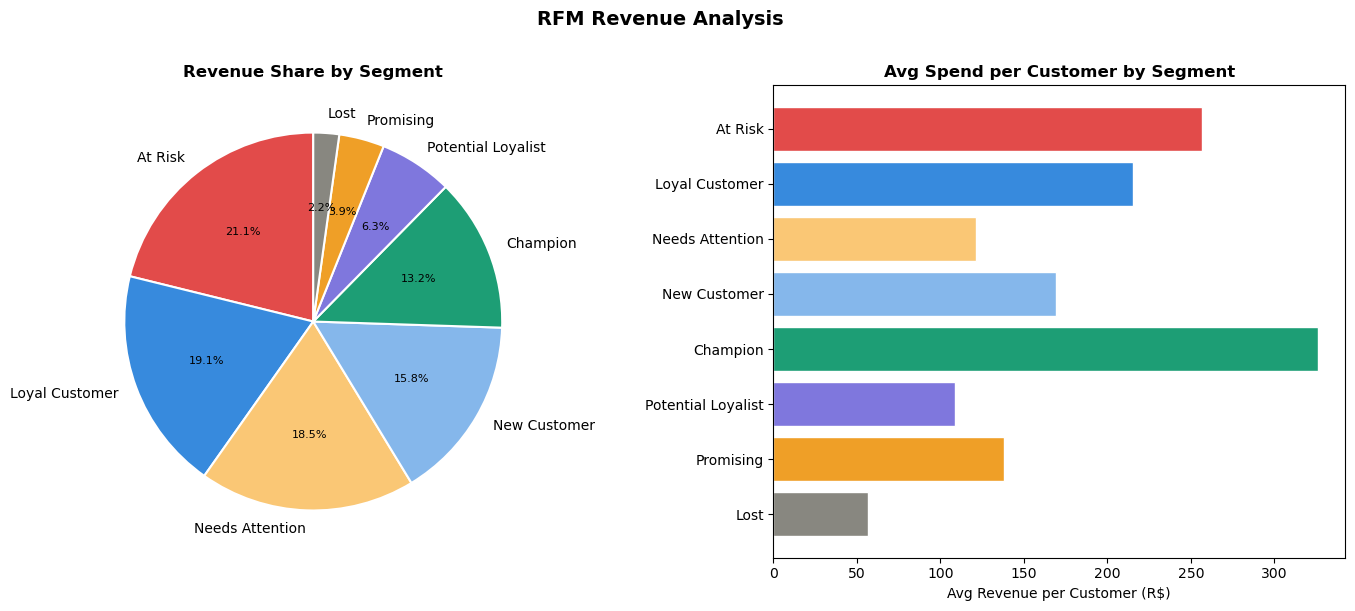

In [14]:
seg_revenue = segment_summary.set_index('segment')['total_revenue']
seg_colors  = [colors_map.get(s, '#888780') for s in seg_revenue.index]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

wedges, texts, autotexts = axes[0].pie(
    seg_revenue.values,
    labels=seg_revenue.index,
    autopct='%1.1f%%',
    colors=seg_colors,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
for text in autotexts:
    text.set_fontsize(8)
axes[0].set_title('Revenue Share by Segment', fontweight='bold')

axes[1].barh(
    segment_summary['segment'],
    segment_summary['avg_monetary'],
    color=seg_colors,
    edgecolor='white'
)
axes[1].set_xlabel('Avg Revenue per Customer (R$)')
axes[1].set_title('Avg Spend per Customer by Segment', fontweight='bold')
axes[1].invert_yaxis()

plt.suptitle('RFM Revenue Analysis', fontsize=14,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'rfm_revenue.png'),
            dpi=150, bbox_inches='tight')
plt.show()

In [15]:
cohort_data = master[['customer_unique_id',
                       'order_id',
                       'order_purchase_timestamp']].copy()

cohort_data['order_month'] = (
    cohort_data['order_purchase_timestamp']
    .dt.to_period('M')
)

cohort_data['cohort_month'] = (
    cohort_data.groupby('customer_unique_id')['order_month']
    .transform('min')
)

print("Sample cohort data:")
print(cohort_data.head(8))

Sample cohort data:
                 customer_unique_id                          order_id  \
0  7c396fd4830fd04220f754e42b4e5bff  e481f51cbdc54678b7cc49136f2d6af7   
1  7c396fd4830fd04220f754e42b4e5bff  e481f51cbdc54678b7cc49136f2d6af7   
2  7c396fd4830fd04220f754e42b4e5bff  e481f51cbdc54678b7cc49136f2d6af7   
3  af07308b275d755c9edb36a90c618231  53cdb2fc8bc7dce0b6741e2150273451   
4  3a653a41f6f9fc3d2a113cf8398680e8  47770eb9100c2d0c44946d9cf07ec65d   
5  7c142cf63193a1473d2e66489a9ae977  949d5b44dbf5de918fe9c16f97b45f8a   
6  72632f0f9dd73dfee390c9b22eb56dd6  ad21c59c0840e6cb83a9ceb5573f8159   
7  80bb27c7c16e8f973207a5086ab329e2  a4591c265e18cb1dcee52889e2d8acc3   

  order_purchase_timestamp order_month cohort_month  
0      2017-10-02 10:56:00     2017-10      2017-09  
1      2017-10-02 10:56:00     2017-10      2017-09  
2      2017-10-02 10:56:00     2017-10      2017-09  
3      2018-07-24 20:41:00     2018-07      2018-07  
4      2018-08-08 08:38:00     2018-08      2018-08 

In [16]:
cohort_data['order_month_int'] = (
    cohort_data['order_month']
    .apply(lambda x: x.ordinal)
)

cohort_data['cohort_month_int'] = (
    cohort_data['cohort_month']
    .apply(lambda x: x.ordinal)
)

cohort_data['cohort_index'] = (
    cohort_data['order_month_int'] -
    cohort_data['cohort_month_int']
)

print("Cohort index sample:")
print(cohort_data[['customer_unique_id', 'order_month',
                    'cohort_month', 'cohort_index']].head(10))

Cohort index sample:
                 customer_unique_id order_month cohort_month  cohort_index
0  7c396fd4830fd04220f754e42b4e5bff     2017-10      2017-09             1
1  7c396fd4830fd04220f754e42b4e5bff     2017-10      2017-09             1
2  7c396fd4830fd04220f754e42b4e5bff     2017-10      2017-09             1
3  af07308b275d755c9edb36a90c618231     2018-07      2018-07             0
4  3a653a41f6f9fc3d2a113cf8398680e8     2018-08      2018-08             0
5  7c142cf63193a1473d2e66489a9ae977     2017-11      2017-11             0
6  72632f0f9dd73dfee390c9b22eb56dd6     2018-02      2018-02             0
7  80bb27c7c16e8f973207a5086ab329e2     2017-07      2017-07             0
8  932afa1e708222e5821dac9cd5db4cae     2017-05      2017-05             0
9  39382392765b6dc74812866ee5ee92a7     2017-01      2017-01             0


In [21]:
cohort_counts = (
    cohort_data.groupby(['cohort_month', 'cohort_index'])
    ['customer_unique_id']
    .nunique()
    .reset_index()
)

cohort_pivot = cohort_counts.pivot_table(
    index='cohort_month',
    columns='cohort_index',
    values='customer_unique_id'
)


cohort_size   = cohort_pivot[0] 
retention     = cohort_pivot.divide(cohort_size, axis=0) * 100
retention = retention.round(1)

print("Cohort retention table (% of customers who returned):")
print(retention.iloc[:6, :6])

Cohort retention table (% of customers who returned):
cohort_index      0      1    2    3    4    5
cohort_month                                  
2016-10       100.0    NaN  NaN  NaN  NaN  NaN
2016-12       100.0  100.0  NaN  NaN  NaN  NaN
2017-01       100.0    0.3  0.3  0.1  0.4  0.1
2017-02       100.0    0.2  0.3  0.1  0.4  0.1
2017-03       100.0    0.4  0.4  0.4  0.4  0.2
2017-04       100.0    0.6  0.2  0.2  0.3  0.3


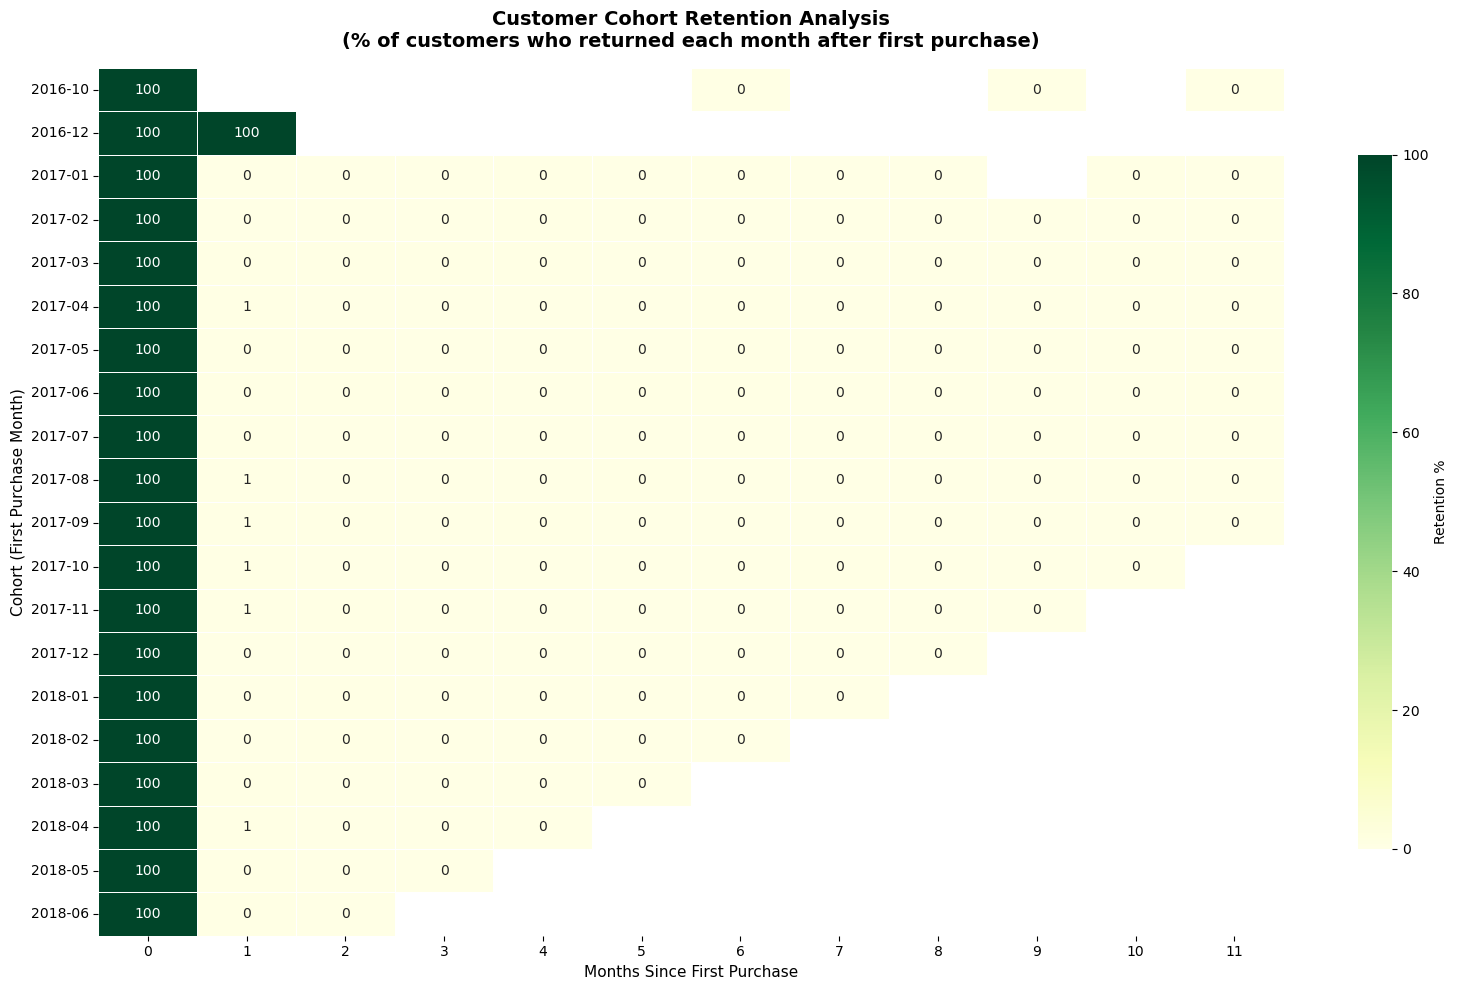

Cohort heatmap saved!


In [22]:
plt.figure(figsize=(16, 10))

retention_plot = retention.iloc[:-2, :12]

retention_plot.index = retention_plot.index.astype(str)

sns.heatmap(
    retention_plot,
    annot=True,         
    fmt='.0f',           
    cmap='YlGn',          
    vmin=0,               
    vmax=100,            
    linewidths=0.5,       
    linecolor='white',
    cbar_kws={'label': 'Retention %', 'shrink': 0.8}
)

plt.title('Customer Cohort Retention Analysis\n'
          '(% of customers who returned each month after first purchase)',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Months Since First Purchase', fontsize=11)
plt.ylabel('Cohort (First Purchase Month)', fontsize=11)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'cohort_retention_heatmap.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Cohort heatmap saved!")

In [23]:
print("=" * 65)
print("KEY BUSINESS INSIGHTS FROM RFM + COHORT ANALYSIS")
print("=" * 65)

champions = rfm[rfm['segment'] == 'Champion']
print(f"\n1. CHAMPIONS ({len(champions):,} customers)")
print(f"   Avg spend    : R$ {champions['monetary'].mean():,.2f}")
print(f"   Avg orders   : {champions['frequency'].mean():.1f}")
print(f"   Revenue share: "
      f"{champions['monetary'].sum()/rfm['monetary'].sum()*100:.1f}%")

at_risk = rfm[rfm['segment'] == 'At Risk']
print(f"\n2. AT RISK CUSTOMERS ({len(at_risk):,} customers)")
print(f"   These were good customers not buying recently")
print(f"   Avg days since last purchase: {at_risk['recency'].mean():.0f} days")
print(f"   Revenue at risk: R$ {at_risk['monetary'].sum():,.2f}")

one_time = rfm[rfm['frequency'] == 1]
print(f"\n3. ONE-TIME BUYERS ({len(one_time):,} customers = "
      f"{len(one_time)/len(rfm)*100:.1f}% of all customers)")
print(f"   This is your retention crisis")
print(f"   9 out of 10 customers NEVER came back")

lost = rfm[rfm['segment'] == 'Lost']
print(f"\n4. LOST CUSTOMERS ({len(lost):,} customers)")
print(f"   Avg recency: {lost['recency'].mean():.0f} days since last purchase")
print(f"   Very expensive to win back — focus on retention instead")

print(f"\n5. COHORT RETENTION FINDING")
print(f"   Month 0 (first purchase) : 100% (by definition)")
print(f"   Month 1 retention        : ~{retention.iloc[:,1].mean():.1f}%")
print(f"   Month 3 retention        : ~{retention.iloc[:,3].mean():.1f}%")
print(f"   CONCLUSION: Massive drop after first purchase")
print(f"   RECOMMENDATION: Launch email re-engagement campaign")
print(f"   Target: customers who bought 60-90 days ago with no repeat")

KEY BUSINESS INSIGHTS FROM RFM + COHORT ANALYSIS

1. CHAMPIONS (6,472 customers)
   Avg spend    : R$ 326.00
   Avg orders   : 1.2
   Revenue share: 13.2%

2. AT RISK CUSTOMERS (13,207 customers)
   These were good customers not buying recently
   Avg days since last purchase: 394 days
   Revenue at risk: R$ 3,392,816.72

3. ONE-TIME BUYERS (90,548 customers = 97.0% of all customers)
   This is your retention crisis
   9 out of 10 customers NEVER came back

4. LOST CUSTOMERS (6,263 customers)
   Avg recency: 397 days since last purchase
   Very expensive to win back — focus on retention instead

5. COHORT RETENTION FINDING
   Month 0 (first purchase) : 100% (by definition)
   Month 1 retention        : ~5.4%
   Month 3 retention        : ~0.2%
   CONCLUSION: Massive drop after first purchase
   RECOMMENDATION: Launch email re-engagement campaign
   Target: customers who bought 60-90 days ago with no repeat


In [24]:
rfm_path = os.path.join(DATA_PATH, "rfm_segments.csv")
rfm.to_csv(rfm_path, index=False)

seg_path = os.path.join(OUTPUT_PATH, "segment_summary.xlsx")
segment_summary.to_excel(seg_path, index=False)

print("Files saved:")
print(f"  rfm_segments.csv    → {rfm_path}")
print(f"  segment_summary.xlsx → {seg_path}")
print(f"\nTotal customers analysed: {len(rfm):,}")
print(f"Segments created: {rfm['segment'].nunique()}")


Files saved:
  rfm_segments.csv    → D:\Data Analytics\Data Analyst Project\E-Commerce Sales & Customer Analytics Dashboard\Dataset\rfm_segments.csv
  segment_summary.xlsx → D:\Data Analytics\Data Analyst Project\E-Commerce Sales & Customer Analytics Dashboard\Dataset\segment_summary.xlsx

Total customers analysed: 93,349
Segments created: 8

Day 5 complete!
